# Week 7: Transfer Learning — BERT & Sentence-BERT

This notebook extends the Transformer architecture from Week 6 into full encoder stacks, then introduces BERT pre-training, fine-tuning, and Sentence-BERT (SBERT) for semantic similarity and retrieval.

## Learning Goals
- Stack multiple `TransformerBlock` layers from `utils.py` to build a complete encoder architecture.
- Understand BERT's bidirectional pre-training objectives: Masked Language Modeling (MLM) and Next Sentence Prediction (NSP).
- Fine-tune a pre-trained BERT model for IMDb sentiment classification using the Hugging Face `Trainer` API.
- Understand why BERT is slow for semantic similarity tasks and how SBERT solves this with a Siamese network.
- Build a semantic similarity pipeline with SBERT embeddings and compare against the Week 3 DAN baseline.

## Reused Assets from Week 6
This week reuses the saved IMDb tokenized assets and the `utils.py` building blocks from previous weeks.

- `../week6-transformer-attention/data/imdb_bpe_dataset.pt` (or the Week 5 path)
- `../week5-CNN-for-text/data/bpe_vocab.json`
- `../week5-CNN-for-text/data/bpe_merges.json`
- `../week5-CNN-for-text/models/vocab_config.json`
- `../week6-transformer-attention/models/tiny_transformer_imdb_rope.pt` (Week 6 checkpoint)

For Day 4 and Day 5, Hugging Face datasets and the `sentence-transformers` library are also required.

## Suggested Multi-Day Flow
- **Day 1:** Stack `TransformerBlock` layers from `utils.py` into a full encoder and probe its representations.
- **Day 2:** Explore BERT's architecture and pre-training objectives (MLM and NSP) without writing them from scratch.
- **Day 3:** Fine-tune a pre-trained BERT model on IMDb using the Hugging Face `Trainer` API.
- **Day 4:** Introduce SBERT and Siamese networks; understand why they are faster for similarity tasks.
- **Day 5:** Build a semantic search pipeline with SBERT embeddings and compare it with the Week 3 DAN baseline.

You can treat each day as one notebook checkpoint instead of trying to finish the full notebook in one sitting.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, random_split

# Reused directly from utils.py — same as Week 6
from utils import (
    create_bert,
    linear_cka,
    TransformerBlock,
    MultiHeadAttention,
    FeedForward,
    bpe_batch_encode,
    evaluate_binary_classifier,
    get_device,
    load_json,
    load_torch_dataset,
    masked_mean_pool,
    plot_attention_heads,
    plot_attention_heatmap,
    plot_training_history,
    train_binary_classifier,
)

In [2]:
# Asset paths — adjust to match your local folder layout
paths = {
    "dataset": Path("../week5-CNN-for-text/data/imdb_bpe_dataset.pt"),
    "bpe_vocab": Path("../week5-CNN-for-text/data/bpe_vocab.json"),
    "bpe_merges": Path("../week5-CNN-for-text/data/bpe_merges.json"),
    "vocab_config": Path("../week5-CNN-for-text/models/vocab_config.json"),
    "dan_state": Path("../week5-CNN-for-text/models/dan_imdb.pt"),
    "week6_rope_model": Path("../week6-transformer/models/tiny_transformer_imdb_rope.pt"),
}

missing = [str(p) for p in paths.values() if not p.exists()]
if missing:
    print("Warning: missing Week 6/5 assets — some cells will need the paths updated:")
    for m in missing:
        print(" ", m)
else:
    print("All asset paths found.")

input_ids, labels, attention_masks = load_torch_dataset(str(paths["dataset"]))
bpe_vocab = load_json(str(paths["bpe_vocab"]))
bpe_merges = [tuple(pair) for pair in load_json(str(paths["bpe_merges"]))]
vocab_config = load_json(str(paths["vocab_config"]))
id_to_token = {idx: token for token, idx in bpe_vocab.items()}
device = get_device()

dan_state = torch.load(paths["dan_state"], map_location=device, weights_only=True)
embedding_weight = dan_state["embedding.weight"].to(device)

print("device:", device)
print("input_ids shape:", tuple(input_ids.shape))
print("labels shape:", tuple(labels.shape))
print("attention_masks shape:", tuple(attention_masks.shape))
print("vocab size:", vocab_config["vocab_size"])
print("pad id:", vocab_config["pad_id"])
print("embedding_weight shape:", tuple(embedding_weight.shape))

All asset paths found.
device: mps
input_ids shape: (50000, 128)
labels shape: (50000,)
attention_masks shape: (50000, 128)
vocab size: 590
pad id: 589
embedding_weight shape: (590, 384)


## Day 1: Building a Full Transformer Encoder

The goal for Day 1 is to stack the `TransformerBlock` layers from `utils.py` into a full encoder and understand how layer depth changes the representations it builds.

### From Block to Encoder

In Week 6 we built and inspected a single `TransformerBlock`. An encoder is simply a stack of those blocks, one after another. Each block receives the output of the previous one as its new `x`, so representations accumulate context across layers.

The full encoder pipeline (if using absolute position encoding) is:

$$
x_0 = \text{Embedding}(\text{input\_ids}) + \text{PositionalEncoding}
$$
$$
x_l = \text{TransformerBlock}_l(x_{l-1}), \quad l = 1, \ldots, L
$$
$$
h = \text{LayerNorm}(x_L)
$$

The `TinyBERT` class from `utils.py` already does exactly this except it uses rotary position encoding — it is a stacked encoder. Today we look *inside* it: we probe the representation at each layer using CKA (Centered Kernel Alignment) to see how much layers agree with each other.

### Layer Similarity with CKA

A simple way to compare representations at two layers is **linear CKA**. For two representation matrices $X$ and $Y$ (each of shape `[n_examples, d]`), linear CKA is:

$$
\text{CKA}(X, Y) = \frac{\lVert Y^T X \rVert_F^2}{\lVert X^T X \rVert_F \cdot \lVert Y^T Y \rVert_F}
$$

CKA ranges from 0 (representations are completely different) to 1 (representations are identical up to linear transformation). It is a useful diagnostic for checking whether later encoder layers are actually building on top of earlier ones or just repeating themselves.

A few things to expect:
- Adjacent layers tend to be more similar (higher CKA) than distant ones.
- The very first and last layers often differ the most — early layers encode surface features while later layers encode more abstract patterns.
- Because our encoder here is untrained (we reuse frozen BPE embeddings and random block weights), the CKA pattern will look noisier than in a trained model.

The Frobenius norm is defined as the square root of the sum of the absolute squares of its elements:

$$ |A|_F = \sqrt{\sum_{i=1}^m \sum_{j=1}^n |a_{ij}|^2} $$

It can also be written elegantly in terms of the matrix trace:

$$ |A|_F = \sqrt{\text{Tr}(A^T A)} $$

In [3]:
# Initialize our TinyBERT encoder from scratch
num_layers = 4
num_heads = 4
vocab_size = vocab_config["vocab_size"]
d_model = embedding_weight.size(1)  
pad_id = vocab_config["pad_id"]

tiny_bert = create_bert(
    vocab_size=vocab_size,
    d_model=d_model,
    num_heads=num_heads,
    mlp_hidden_dim=4 * d_model,
    num_layers=num_layers,
    pad_id=pad_id,
    use_rope=True,
    use_absolute_positions=False,
    pretrained_embedding_weight=embedding_weight.detach().cpu()
).to(device)


print(f"TinyBERT Parameters: {sum(p.numel() for p in tiny_bert.parameters())}")
print(tiny_bert)

TinyBERT Parameters: 7325184
TinyBERT(
  (embedding): Embedding(590, 384, padding_idx=589)
  (dropout): Dropout(p=0.1, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (self_attn_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (self_attn): MultiHeadAttention(
        (q_proj): Linear(in_features=384, out_features=384, bias=True)
        (k_proj): Linear(in_features=384, out_features=384, bias=True)
        (v_proj): Linear(in_features=384, out_features=384, bias=True)
        (out_proj): Linear(in_features=384, out_features=384, bias=True)
      )
      (ffn_norm): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=384, out_features=1536, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.1, inplace=False)
          (3): Linear(in_features=1536, out_features=384, bias=True)
          (4): Dropout(p=0.1, inplace=False)
     

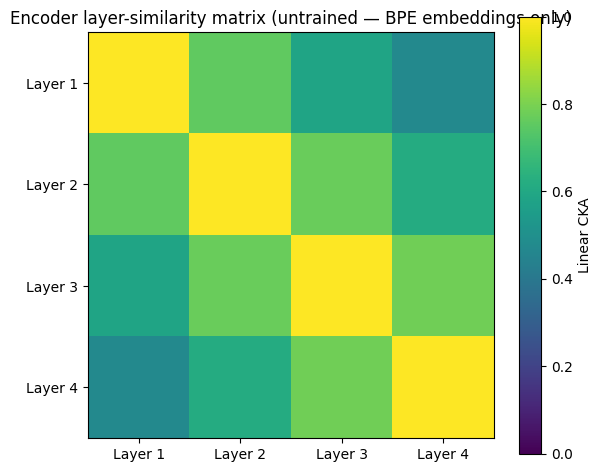

CKA matrix (row i, col j = similarity between layer i and layer j):
tensor([[1.0000, 0.7570, 0.5850, 0.4730],
        [0.7570, 1.0000, 0.7700, 0.6170],
        [0.5850, 0.7700, 1.0000, 0.7850],
        [0.4730, 0.6170, 0.7850, 1.0000]])


In [7]:
tiny_bert.eval()

probe_size = 128
probe_ids = input_ids[:probe_size, :].to(device)
probe_masks = attention_masks[:probe_size, :].to(device)

# Collect layer representations manually
layer_reps = []
with torch.no_grad():
    x = tiny_bert.embedding(probe_ids)
    x = tiny_bert.dropout(x)
    for block in tiny_bert.blocks:
        x = block(x=x, attention_mask=probe_masks)
        pooled = masked_mean_pool(x, probe_masks)  # [n, d]
        layer_reps.append(pooled.detach().cpu())

# Compute pairwise CKA
n_layers = len(layer_reps)
cka_matrix = torch.zeros(n_layers, n_layers)
for i in range(n_layers):
    for j in range(n_layers):
        cka_matrix[i, j] = linear_cka(layer_reps[i], layer_reps[j])

plt.figure(figsize=(6, 5))
plt.imshow(cka_matrix.numpy(), vmin=0, vmax=1, cmap="viridis")
plt.colorbar(label="Linear CKA")
plt.xticks(range(n_layers), [f"Layer {i+1}" for i in range(n_layers)])
plt.yticks(range(n_layers), [f"Layer {i+1}" for i in range(n_layers)])
plt.title("Encoder layer-similarity matrix (untrained — BPE embeddings only)")
plt.tight_layout()
plt.show()

print("CKA matrix (row i, col j = similarity between layer i and layer j):")
print(cka_matrix.round(decimals=3))

## Day 2: BERT Architecture & Pre-training

**Goal:** Introduce BERT (Bidirectional Encoder Representations from Transformers). Explore its Masked Language Modeling (MLM) and Next Sentence Prediction (NSP) objectives.

In [ ]:
# Simulating the Masked Language Modeling (MLM) logic
def create_mlm_labels(input_ids, mask_token_id, pad_token_id, mask_prob=0.15):
    """
    A simplified version of MLM masking.
    """
    labels = input_ids.clone()
    
    # Create a random probability matrix for tokens
    prob_matrix = torch.rand(input_ids.shape)
    
    # Don't mask padding tokens
    prob_matrix.masked_fill_(input_ids == pad_token_id, 1.0)
    
    # Mask tokens where prob < mask_prob
    masked_indices = prob_matrix < mask_prob
    
    # Set masked inputs to mask_token_id
    inputs_masked = input_ids.clone()
    inputs_masked[masked_indices] = mask_token_id
    
    # We only compute loss on masked tokens, set others to -100 (ignored by CrossEntropyLoss)
    labels[~masked_indices] = -100 
    
    return inputs_masked, labels

dummy_inputs = torch.randint(1, vocab_size, (2, 20))
masked_inputs, labels = create_mlm_labels(dummy_inputs, mask_token_id=1, pad_token_id=0)
print("Original:", dummy_inputs[0][:10])
print("Masked:  ", masked_inputs[0][:10])
print("Labels:  ", labels[0][:10])

## Day 3: Fine-tuning BERT

**Goal:** Hands-on with fine-tuning a pre-trained BERT model for a classification task using the Hugging Face `Trainer` API.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import load_dataset

# 1. Load the IMDB dataset (our anchor dataset)
# dataset = load_dataset("imdb")

# 2. Load pre-trained BERT tokenizer and model for sequence classification
model_name = "prajjwal1/bert-tiny" # Using a tiny BERT for speed
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

# 3. Example tokenization
sample_text = "This movie was absolutely fantastic!"
tokens = tokenizer(sample_text, return_tensors="pt")
print("Tokens:", tokens)

# 4. Forward pass
outputs = model(**tokens)
print("Logits:", outputs.logits)

## Day 4: Sentence-BERT (SBERT) and Siamese Networks

**Goal:** Introduce SBERT and Siamese networks. Understand why standard BERT is slow for semantic similarity and how SBERT solves this by producing sentence embeddings.

In [ ]:
from utils import create_sbert

# We can wrap our previously created TinyBERT in our SBERT wrapper
# This will apply Mean Pooling to the BERT outputs and L2 normalize them.
tiny_sbert = create_sbert(tiny_bert)

dummy_attention_mask = torch.ones_like(dummy_inputs)
sentence_embeddings = tiny_sbert(dummy_inputs, dummy_attention_mask)

print(f"Sentence embeddings shape: {sentence_embeddings.shape} (batch_size, d_model)")
print(f"Vector norm (should be 1.0 due to L2 normalization): {torch.norm(sentence_embeddings[0]).item():.4f}")

## Day 5: SBERT in Action (Semantic Search)

**Goal:** Implement semantic search or retrieval using SBERT embeddings and compare performance with Week 3's baseline.

In [ ]:
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer

# Load a pre-trained SBERT model
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

sentences = [
    "The weather is lovely today.",
    "It's so sunny outside!",
    "He drove a fast car."
]

# Generate embeddings
embeddings = sbert_model.encode(sentences, convert_to_tensor=True)

# Compute Cosine Similarities
sim_0_1 = F.cosine_similarity(embeddings[0].unsqueeze(0), embeddings[1].unsqueeze(0))
sim_0_2 = F.cosine_similarity(embeddings[0].unsqueeze(0), embeddings[2].unsqueeze(0))

print(f"Similarity ('{sentences[0]}' vs '{sentences[1]}'): {sim_0_1.item():.4f}")
print(f"Similarity ('{sentences[0]}' vs '{sentences[2]}'): {sim_0_2.item():.4f}")